URL index: [Home](https://zzz.bwh.harvard.edu/luna-walkthrough/) | [Data](https://zzz.bwh.harvard.edu/luna-walkthrough/data/) | [S1. File QC](https://zzz.bwh.harvard.edu/luna-walkthrough/p1/) | [S2. Signal QC](https://zzz.bwh.harvard.edu/luna-walkthrough/p2) | [S3. Staging](https://zzz.bwh.harvard.edu/luna-walkthrough/p3) | [S4. Artifacts](https://zzz.bwh.harvard.edu/luna-walkthrough/p4) | [S5. Analysis](https://zzz.bwh.harvard.edu/luna-walkthrough/p5)

Notebook index: [Index](../00_index.ipynb) | [S1. File QC](../p1/00_index.ipynb) | [S2. Signal QC](../p2/00_index.ipynb) | [S3. Staging](../p3/00_index.ipynb) | [S4. Artifacts](../p4/00_index.ipynb) | [S5. Analysis](../p5/00_index.ipynb)

---

# 5.3. Quantifying ultradian dynamics

Walkthrough URL = [https://zzz.bwh.harvard.edu/luna-walkthrough/p5/dynam](https://zzz.bwh.harvard.edu/luna-walkthrough/p5/dynam)

---


In [1]:
import lunapi as lp
proj = lp.proj()
proj.sample_list( '../c.lst' )

initiated lunapi v1.2.3 <lunapi.lunapi0.luna object at 0x10c30bef0> 

read 20 individuals from ../c.lst


In [2]:
import sys
sys.path.append('../')
from helperfuncs import safe_to_numeric

## Cycle-level dynamics

In [3]:
#luna c.lst -o out/cycles.db \
#  -s ' ${z=FZ,CZ,PZ,OZ}
#       HYPNO annot
#
#       MASK ifnot=N2,N3 & RE
#       CHEP-MASK sig=${z} ep-th=3,3
#       CHEP sig=${z} epochs & RE
#
#       MASK ifnot=h_cycle_n1
#       TAG P/C1
#       PSD sig=${z} dB
#
#       MASK ifnot=h_cycle_n2
#       TAG P/C2
#       PSD sig=${z} dB
#
#       MASK ifnot=h_cycle_n3
#       TAG P/C3
#       PSD sig=${z} dB
#
#       MASK ifnot=h_cycle_n4
#       TAG P/C4
#       PSD sig=${z} dB '

res = proj.silent_proc( '''
    ${z=FZ,CZ,PZ,OZ}
    HYPNO annot

    MASK ifnot=N2,N3 & RE
    CHEP-MASK sig=${z} ep-th=3,3
    CHEP sig=${z} epochs & RE

    MASK ifnot=h_cycle_n1
    TAG P/C1
    PSD sig=${z} dB

    MASK ifnot=h_cycle_n2
    TAG P/C2
    PSD sig=${z} dB

    MASK ifnot=h_cycle_n3
    TAG P/C3
    PSD sig=${z} dB

    MASK ifnot=h_cycle_n4
    TAG P/C4
    ''')



In [4]:
# alternatively, using the newer LOOP function (requires recent version of Luna)
# could use vals=[][1:4] also in the LOOP below

res = proj.silent_proc( '''
    ${z=FZ,CZ,PZ,OZ}
    HYPNO annot

    MASK ifnot=N2,N3 & RE
    CHEP-MASK sig=${z} ep-th=3,3
    CHEP sig=${z} epochs & RE

    LOOP index=cyc vals=1,2,3,4
      MASK ifnot=h_cycle_n#{cyc}
      TAG P/C#{cyc}
      PSD sig=${z} dB
    END-LOOP
    ''')


In [5]:
# destrat out/cycles.db +PSD \
#    -r CH P \
#    -r B/SLOW,DELTA,THETA,ALPHA,SIGMA,FAST_SIGMA,SLOW_SIGMA,BETA \
#    -v PSD > res/dynam.cycles
df = proj.table( 'PSD' , 'B_CH_P' )
df = df[ df.B.isin( [ 'SLOW', 'DELTA', 'THETA', 'ALPHA', 'SIGMA', 'FAST_SIGMA', 'SLOW_SIGMA', 'BETA' ] ) ] 
df

,ID,B,CH,P,PSD,RELPSD
0,F01,ALPHA,CZ,C1,14.533907,0.045816
1,F02,ALPHA,CZ,C1,14.036062,0.020702
2,F03,ALPHA,CZ,C1,15.498486,0.038318
3,F04,ALPHA,CZ,C1,11.945512,0.017164
4,F05,ALPHA,CZ,C1,14.078799,0.022342
...,...,...,...,...,...,...
2695,M05,THETA,PZ,C4,12.98342,0.107296
2696,M07,THETA,PZ,C4,12.198845,0.05529
2697,M08,THETA,PZ,C4,13.453524,0.05241
2698,M09,THETA,PZ,C4,16.125004,0.130623


We can summarize cycle-, channel- and band-specific power values as follows:

In [6]:
# res <- tapply( d$PSD , list( d$P, d$CH , d$B ) , mean )
r = df.groupby( [ 'P', 'CH', 'B' ] )['PSD'].mean()
r

P   CH  B         
C1  CZ  ALPHA         12.469121
        BETA           7.092314
        DELTA         24.421553
        FAST_SIGMA      9.63613
        SIGMA         11.119786
                        ...    
C4  PZ  FAST_SIGMA     8.132888
        SIGMA          9.469618
        SLOW          19.776082
        SLOW_SIGMA     7.891311
        THETA          13.93113
Name: PSD, Length: 128, dtype: object

To see whether, For example, N2 delta power is (on average) reduced over NREM cycles:

In [7]:
# res[,,"DELTA"]
delta = r.xs('DELTA', level='B').unstack().T
delta = delta.reset_index()
delta = delta.set_index('CH')
delta = delta.loc[ ['FZ', 'CZ', 'PZ', 'PZ' ] ]
delta

P,C1,C2,C3,C4
CH,,,,
FZ,25.547935,23.988122,22.831848,22.21806
CZ,24.421553,22.694804,21.670519,21.070293
PZ,21.716396,20.235208,19.31206,18.592874
PZ,21.716396,20.235208,19.31206,18.592874


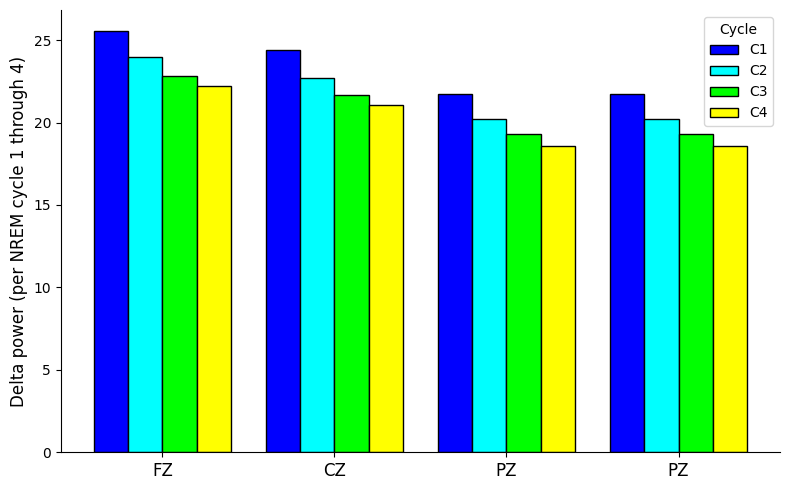

In [8]:
#barplot( res[ , c("FZ","CZ","PZ","OZ") , "DELTA" ] ,
#         beside = T , col = topo.colors(4) ,
#         ylab = "Delta power (per NREM cycle 1 through 4)" ) 

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

colors = ['blue', 'cyan', 'lime', 'yellow']
width = 0.2
x = np.arange(len(delta.index))

fig, ax = plt.subplots(figsize=(8, 5))
for i, col in enumerate(delta.columns):
    ax.bar(x + i * width, delta[col].values, width,
           label=col, color=colors[i], edgecolor='black')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(delta.index, fontsize=12)
ax.set_ylabel('Delta power (per NREM cycle 1 through 4)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(title='Cycle')
plt.tight_layout()
plt.show()

Test, and control for age/sex, we'll merge in the demographic data:

In [9]:
p = pd.read_csv( '../work/data/auxiliary/master.txt' , sep="\t" ) 
df   = pd.merge( p , df , on = 'ID' ) 
df

,ID,male,age,B,CH,P,PSD,RELPSD
0,F01,0,41,ALPHA,CZ,C1,14.533907,0.045816
1,F01,0,41,ALPHA,CZ,C2,14.599212,0.069461
2,F01,0,41,ALPHA,CZ,C3,14.427021,0.073384
3,F01,0,41,ALPHA,CZ,C4,12.603518,0.06606
4,F01,0,41,ALPHA,FZ,C1,16.889736,0.058155
...,...,...,...,...,...,...,...,...
2395,M10,1,41,THETA,OZ,C4,7.198694,0.022649
2396,M10,1,41,THETA,PZ,C1,10.437095,0.014633
2397,M10,1,41,THETA,PZ,C2,9.000746,0.015374
2398,M10,1,41,THETA,PZ,C3,8.056696,0.017571


In [10]:
# summary(lm( PSD ~ male + age + as.factor( P ) , data = d , subset = B == "DELTA" & CH == "CZ"  ) )

import statsmodels.formula.api as smf
df1 = df[ ( df.CH == 'CZ' ) & ( df.B == 'DELTA' ) ].copy() 
df1 = safe_to_numeric( df1 ) 
# nb. basic model, ignores non-independence between cycles w/in indiv
#   i.e. would want to use mixed models in practice.
model = smf.ols('PSD ~ age + male + P ', data=df1).fit()
print( model.summary() ) 

                            OLS Regression Results                            
Dep. Variable:                    PSD   R-squared:                       0.481
Model:                            OLS   Adj. R-squared:                  0.443
Method:                 Least Squares   F-statistic:                     12.77
Date:                Fri, 13 Jun 2025   Prob (F-statistic):           8.54e-09
Time:                        14:10:28   Log-Likelihood:                -151.78
No. Observations:                  75   AIC:                             315.6
Df Residuals:                      69   BIC:                             329.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     29.7108      1.608     18.477      0.0

## Epoch-level dynamics

In [11]:
#luna c.lst -o out/dynam.db \
#  -s ' HYPNO
#       MASK ifnot=N2,N3 & RE
#       CHEP-MASK sig=CPZ ep-th=3,3
#       CHEP epochs & RE
#       PSD sig=CPZ dynam dynam-max-cycle=4 dynam-norm-cycles=F '

res = proj.silent_proc( '''
  HYPNO
  MASK ifnot=N2,N3 & RE
  CHEP-MASK sig=CPZ ep-th=3,3
  CHEP epochs & RE
  PSD sig=CPZ dynam dynam-max-cycle=4 dynam-norm-cycles=F '
  ''' )

In [12]:
# destrat out/dynam.db +PSD -r CH VAR B QD   > res/dynam.band.1
# destrat out/dynam.db +PSD -r CH VAR B Q QD > res/dynam.band.2
df1 = proj.table( 'PSD' , 'B_CH_QD_VAR' ) 
df2 = proj.table( 'PSD' , 'B_CH_Q_QD_VAR' ) 

In [13]:
df1

,ID,B,CH,QD,VAR,A_P2P,MEAN,N,OMEAN,SD,T_P2P,U,U2
0,F01,ALPHA,CPZ,BETWEEN,PSD,None,0.904459,4,None,0.259717,None,-0.670538,-0.615916
1,F02,ALPHA,CPZ,BETWEEN,PSD,None,1.038646,4,None,0.131352,None,-0.116177,0.796374
2,F03,ALPHA,CPZ,BETWEEN,PSD,None,0.958851,4,None,0.316727,None,-0.918569,0.368211
3,F04,ALPHA,CPZ,BETWEEN,PSD,None,1.04933,4,None,0.255092,None,-0.767368,-0.625917
4,F05,ALPHA,CPZ,BETWEEN,PSD,None,1.002274,3,None,0.199555,None,-0.648193,-0.762401
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1335,M05,TOTAL,CPZ,W_C4,PSD,0.613245,0.714813,132,0.714813,0.171264,-26.0,0.015909,-0.169775
1336,M07,TOTAL,CPZ,W_C4,PSD,1.144935,0.610738,97,0.610738,0.392358,90.0,0.823941,-0.171598
1337,M08,TOTAL,CPZ,W_C4,PSD,0.862352,0.898883,147,0.898883,0.240337,-31.0,0.357318,-0.100966
1338,M09,TOTAL,CPZ,W_C4,PSD,1.210237,0.682339,128,0.682339,0.412151,97.0,0.851658,-0.176379


In [14]:
df2

,ID,B,CH,Q,QD,VAR,OS,SS
0,F01,ALPHA,CPZ,1,TOT,PSD,14.236441,1.523822
1,F02,ALPHA,CPZ,1,TOT,PSD,12.865935,1.314638
2,F03,ALPHA,CPZ,1,TOT,PSD,15.312251,1.846147
3,F04,ALPHA,CPZ,1,TOT,PSD,12.374009,1.894895
4,F05,ALPHA,CPZ,1,TOT,PSD,14.130798,1.203059
...,...,...,...,...,...,...,...,...
9495,M05,TOTAL,CPZ,9,W_C4,PSD,None,0.684977
9496,M07,TOTAL,CPZ,9,W_C4,PSD,None,1.210571
9497,M08,TOTAL,CPZ,9,W_C4,PSD,None,1.144544
9498,M09,TOTAL,CPZ,9,W_C4,PSD,None,1.194694


In [15]:
# bands <- c("SLOW", "DELTA","THETA","ALPHA","SLOW_SIGMA","FAST_SIGMA","BETA" ) 
#r <- tapply( d$U , list( B = d$B , QD = d$QD  ) , mean ) 
#r[ bands , ]

bands = [ 'SLOW' , 'DELTA' , 'THETA' , 'ALPHA' , 'SLOW_SIGMA' , 'FAST_SIGMA' , 'BETA' ] 
r = df1.pivot_table(index='B', columns='QD', values='U', aggfunc='mean')
r.loc[ bands ] 


QD,BETWEEN,TOT,WITHIN,W_C1,W_C2,W_C3,W_C4
B,,,,,,,
SLOW,-0.696505,-0.344423,0.161163,0.071448,0.120332,0.268892,0.419506
DELTA,-0.834489,-0.466566,0.074349,-0.211366,0.200366,0.276461,0.560094
THETA,-0.839777,-0.610618,-0.145375,-0.685743,0.156916,0.24112,0.266911
ALPHA,-0.465503,-0.321168,-0.116936,-0.503041,0.025409,0.203775,0.194765
SLOW_SIGMA,-0.353206,-0.196076,-0.133767,-0.415223,-0.028307,0.013035,0.222771
FAST_SIGMA,0.229543,0.055147,-0.151762,-0.347597,-0.153943,-0.099171,0.235317
BETA,0.245464,0.030753,-0.070277,-0.158644,-0.037431,-0.006185,-0.20107


_(the remaining plots in this section are skipped currently)_

To understand the primary nature of these types of dynamic chamges, it can often be useful to more directly plot how power changes over time. This information is implicit in `df2`, which has the (normalized) power values for each individual, split by decile of each period (either the whole night, TOT, or within a given NREM cycle, e.g. W_C1).

In [16]:
# r <- tapply( d$SS , list( d$Q , d$QD , d$B ) , mean )
df2 = safe_to_numeric( df2 ) 
r = df2.groupby( [ 'B', 'Q', 'QD' ] )['SS'].mean()
r.unstack()

QD             TOT      W_C1      W_C2      W_C3      W_C4
B     Q                                                   
ALPHA 1   1.487927  1.547714  0.841158  0.578621  0.654870
      2   1.112328  1.691073  1.064207  0.803565  0.788471
      3   1.014273  1.395639  1.071354  0.988932  0.883664
      4   0.950512  1.204983  1.035796  0.968897  0.925217
      5   0.989710  1.240318  1.011664  0.947948  0.929370
...            ...       ...       ...       ...       ...
TOTAL 6   1.009061  1.335606  1.405493  1.017209  0.606674
      7   0.931851  1.298781  1.230504  0.982229  0.651535
      8   0.780978  1.318000  1.115707  0.862477  0.718258
      9   0.694191  1.270977  1.066010  0.801376  0.766699
      10  0.612958  0.904052  0.917559  0.628361  0.701903

[100 rows x 5 columns]

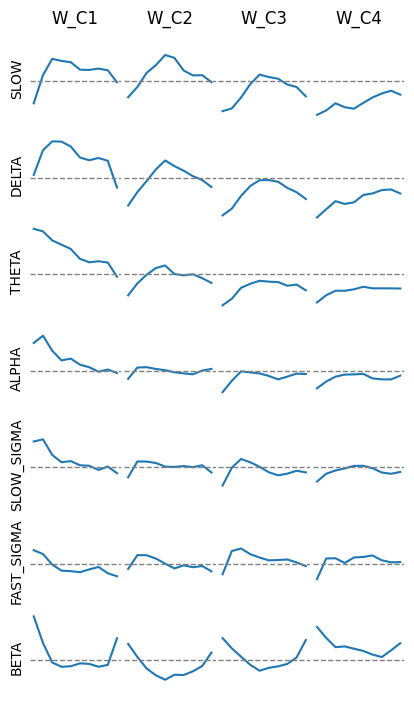

In [17]:
# to plot as per the original walk-through

b = 'DELTA' 
cycs = [ 'W_C1', 'W_C2', 'W_C3', 'W_C4' ] 

fig, axes = plt.subplots(len(bands), len(cycs), figsize=(4, 7), sharey=True)

for i, b in enumerate(bands):
    for j, cyc in enumerate(cycs):
        ax = axes[i, j]
        rr = r.xs((b, cyc), level=('B', 'QD'))
        ax.plot(rr)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.axhline(y=1, color='gray', linestyle='--', linewidth=1)
        for spine in ax.spines.values():
           spine.set_visible(False)

        if i == 0:
            ax.set_title(cyc)
        if j == 0:
            ax.set_ylabel(b)

plt.tight_layout(pad=0.2)
plt.show()

## Summary

In this section we've seen some simple ways to:

 - obtain power values stratified by NREM cycle

 - quantify relative dynamics both within and between NREM cycles

 - visualize band-specific group-level ultradian dynamics in the sleep EEG

We'll include some of the key metrics from dynam in the association modelling step below.

---
We're now ready to move to the [next section](004_conn.ipynb) on connectivity.